# 04k — E5 FreqBlender + SBI EfficientNet-B4 FaceForensics++ Internal Evaluation

**Experiment:** E5 — EfficientNet-B4/380 trained with official SBI plus the authors' frozen FreqBlender FPNet intervention  
**Evaluation dataset:** Genuine FaceForensics++ real and manipulated face-crop test frames

This is evaluation only. It strictly loads `efficientnet_b4_freqblender_sbi_best.pth`; it never trains or updates model weights. SBI generation, FPNet, DCT and FreqBlender are deliberately absent during testing because they are training-time synthetic-data components.


## Evaluation protocol

- Use the audited native-380 FF++ `face_dataset_b4/test` files.
- Require the exact same 292 real and 299 fake frame filenames evaluated for E3d, preserving a matched E3d→E5 comparison.
- Validate that every stored crop is exactly 380×380 before inference.
- Match E5 detector preprocessing: convert to float32 and divide by 255; no ImageNet mean/std normalisation.
- Use the fixed threshold 0.5 with fake as the positive class.
- Aggregate video predictions by mean frame fake probability.
- Report frame- and video-level accuracy, macro precision, macro recall, macro F1, fake recall, ROC-AUC, class reports and confusion matrices.
- Do not generate SBI samples, load FPNet, perform DCT processing, apply FreqBlender, retrain, adapt, select a checkpoint or tune the threshold on the test set.

**Primary comparison:** E5 versus E3d. Both use EfficientNet-B4, native 380×380 crops, the same FF++ source data and split, the same optimiser/training budget, and the same genuine test identities. The intended training-time difference is FreqBlender applied to approximately 20% of dynamically generated SBI fakes.

Internal evaluation measures fit to genuine FF++ manipulations. Generalisation remains untested until the independently prepared Celeb-DF evaluation is run without retraining.


## 1. Evaluation and overwrite controls


In [1]:
RUN_EVALUATION = True
ALLOW_RESULT_OVERWRITE = False

DECISION_THRESHOLD = 0.5
BATCH_SIZE = 8
NUM_WORKERS = 0

assert DECISION_THRESHOLD == 0.5
print("E5 FF++ evaluation enabled:", RUN_EVALUATION)
print("Allow result overwrite:", ALLOW_RESULT_OVERWRITE)
print("Decision threshold:", DECISION_THRESHOLD)


E5 FF++ evaluation enabled: True
Allow result overwrite: False
Decision threshold: 0.5


## 2. Imports, paths and device


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
import json
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b4
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve,
)

BASE_PATH = "/content/drive/MyDrive/deepfake_project"
TEST_DIR = os.path.join(BASE_PATH, "face_dataset_b4", "test")
E3B_REFERENCE_DIR = os.path.join(BASE_PATH, "face_dataset", "test")
SPLIT_MANIFEST_PATH = os.path.join(BASE_PATH, "ffpp_video_split_manifest.json")
CHECKPOINT_PATH = os.path.join(BASE_PATH, "saved_models", "efficientnet_b4_freqblender_sbi_best.pth")
RESULTS_PATH = os.path.join(BASE_PATH, "results", "e5_b4_ffpp_evaluation.json")
CONFUSION_PLOT_PATH = os.path.join(BASE_PATH, "plots", "e5_b4_ffpp_confusion_matrix.png")
ROC_PLOT_PATH = os.path.join(BASE_PATH, "plots", "e5_b4_ffpp_roc_curve.png")
VIDEO_CONFUSION_PLOT_PATH = os.path.join(BASE_PATH, "plots", "e5_b4_ffpp_video_confusion_matrix.png")
VIDEO_ROC_PLOT_PATH = os.path.join(BASE_PATH, "plots", "e5_b4_ffpp_video_roc_curve.png")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Test data:", TEST_DIR)
print("E3b filename reference:", E3B_REFERENCE_DIR)
print("Checkpoint:", CHECKPOINT_PATH)
print("Split manifest:", SPLIT_MANIFEST_PATH)


for output_path in (
    RESULTS_PATH,
    CONFUSION_PLOT_PATH,
    ROC_PLOT_PATH,
    VIDEO_CONFUSION_PLOT_PATH,
    VIDEO_ROC_PLOT_PATH,
):
    if RUN_EVALUATION and os.path.exists(output_path) and not ALLOW_RESULT_OVERWRITE:
        raise FileExistsError(
            f"Evaluation output already exists: {output_path}. "
            "Set ALLOW_RESULT_OVERWRITE = True only if replacement is intentional."
        )


Mounted at /content/drive
Device: cuda
Test data: /content/drive/MyDrive/deepfake_project/face_dataset_b4/test
E3b filename reference: /content/drive/MyDrive/deepfake_project/face_dataset/test
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b4_freqblender_sbi_best.pth
Split manifest: /content/drive/MyDrive/deepfake_project/ffpp_video_split_manifest.json


## 3. Validate E5 preprocessing and the clean genuine FF++ test split


In [5]:
IMAGE_SIZE = 380
REAL_INDEX = 0
FAKE_INDEX = 1

def image_to_tensor(image):
    if image.shape[:2] != (IMAGE_SIZE, IMAGE_SIZE):
        raise ValueError(f"Expected native 380x380 crop, received {image.shape[:2]}")
    image = image.astype(np.float32) / 255.0
    image = image.transpose(2, 0, 1)
    return torch.tensor(image, dtype=torch.float32)

class GenuineFFPPFaceDataset(Dataset):
    def __init__(self, root_path):
        self.samples = []
        for class_name, label in (("real", REAL_INDEX), ("fake", FAKE_INDEX)):
            class_dir = os.path.join(root_path, class_name)
            if not os.path.isdir(class_dir):
                raise FileNotFoundError(class_dir)
            for file_name in sorted(os.listdir(class_dir)):
                if not file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
                    continue
                stem = os.path.splitext(file_name)[0]
                if "_frame_" not in stem:
                    raise ValueError(f"Cannot recover source-video id from: {file_name}")
                self.samples.append({
                    "path": os.path.join(class_dir, file_name),
                    "label": label,
                    "class_name": class_name,
                    "video_id": stem.rsplit("_frame_", 1)[0],
                })
        if not self.samples:
            raise RuntimeError("No genuine FF++ face crops were found.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        image_bgr = cv2.imread(sample["path"])
        if image_bgr is None:
            raise RuntimeError(f"Could not read: {sample['path']}")
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        return image_to_tensor(image_rgb), sample["label"]

assert os.path.isfile(SPLIT_MANIFEST_PATH), f"Split manifest not found: {SPLIT_MANIFEST_PATH}"
test_dataset = GenuineFFPPFaceDataset(TEST_DIR)

invalid_dimensions = []
for sample in test_dataset.samples:
    image = cv2.imread(sample["path"])
    if image is None or image.shape[:2] != (IMAGE_SIZE, IMAGE_SIZE):
        invalid_dimensions.append((sample["path"], None if image is None else image.shape[:2]))
if invalid_dimensions:
    raise RuntimeError(f"Invalid B4 crop dimensions: {invalid_dimensions[:5]}")

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)

class_counts = {
    "real": sum(sample["label"] == REAL_INDEX for sample in test_dataset.samples),
    "fake": sum(sample["label"] == FAKE_INDEX for sample in test_dataset.samples),
}
if class_counts != {"real": 292, "fake": 299}:
    raise RuntimeError(f"Unexpected test class counts: {class_counts}")

for class_name in ("real", "fake"):
    b4_names = {sample["path"].rsplit(os.sep, 1)[-1] for sample in test_dataset.samples if sample["class_name"] == class_name}
    reference_dir = os.path.join(E3B_REFERENCE_DIR, class_name)
    if not os.path.isdir(reference_dir):
        raise FileNotFoundError(f"E3b reference folder not found: {reference_dir}")
    reference_names = {name for name in os.listdir(reference_dir) if name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))}
    if b4_names != reference_names:
        raise RuntimeError(f"E5 and E3b {class_name} frame identities differ.")

with open(SPLIT_MANIFEST_PATH, "r", encoding="utf-8") as handle:
    split_manifest = json.load(handle)

ordered_frame_video_ids = [sample["video_id"] for sample in test_dataset.samples]
actual_test_video_ids = set(ordered_frame_video_ids)
expected_test_video_ids = {
    os.path.splitext(video_name)[0]
    for class_splits in split_manifest["classes"].values()
    for video_name in class_splits["test"]
}
if actual_test_video_ids != expected_test_video_ids:
    raise RuntimeError("E5 test crops do not match the saved video split manifest.")

for class_name, class_splits in split_manifest["classes"].items():
    split_ids = {split: {os.path.splitext(name)[0] for name in names} for split, names in class_splits.items()}
    if split_ids["train"] & split_ids["val"] or split_ids["train"] & split_ids["test"] or split_ids["val"] & split_ids["test"]:
        raise RuntimeError(f"Source-video overlap detected for class {class_name}")

print("Canonical label mapping: {'real': 0, 'fake': 1}")
print("Class counts:", class_counts)
print("Images:", len(test_dataset))
print("Source videos:", len(actual_test_video_ids))
print("PASS: E5 frame filenames exactly match the E3d evaluation subset (and its E3b filename reference).")
print("PASS: genuine test data matches the clean video-level manifest.")
print("Real output index:", REAL_INDEX)
print("Fake output index:", FAKE_INDEX)


sample_tensor, _ = test_dataset[0]
print("Stored crop resolution: 380x380")
print("B4 model input shape:", tuple(sample_tensor.shape))
print("B4 preprocessing: native 380x380 -> float32 -> divide by 255")
print("ImageNet mean/std normalisation: disabled")


Canonical label mapping: {'real': 0, 'fake': 1}
Class counts: {'real': 292, 'fake': 299}
Images: 591
Source videos: 60
PASS: E5 frame filenames exactly match the E3d evaluation subset (and its E3b filename reference).
PASS: genuine test data matches the clean video-level manifest.
Real output index: 0
Fake output index: 1
Stored crop resolution: 380x380
B4 model input shape: (3, 380, 380)
B4 preprocessing: native 380x380 -> float32 -> divide by 255
ImageNet mean/std normalisation: disabled


## 4. Rebuild EfficientNet-B4 and strictly load the E5 checkpoint


In [6]:
assert os.path.isfile(CHECKPOINT_PATH), f"E5 checkpoint not found: {CHECKPOINT_PATH}"

model = efficientnet_b4(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint.get("model_state_dict", checkpoint) if isinstance(checkpoint, dict) else checkpoint
state_dict = {key.removeprefix("module."): value for key, value in state_dict.items()}
model.load_state_dict(state_dict, strict=True)
if isinstance(checkpoint, dict) and checkpoint.get("classes") not in (None, ["real", "fake"]):
    raise RuntimeError(f"Unexpected checkpoint class order: {checkpoint.get('classes')}")
model = model.to(DEVICE)
model.eval()

print("E5 checkpoint loaded successfully.")
if isinstance(checkpoint, dict):
    print("Checkpoint epoch:", checkpoint.get("epoch"))
    print("Synthetic validation accuracy:", checkpoint.get("best_val_accuracy"))
    print("Synthetic validation ROC-AUC:", checkpoint.get("best_val_auc"))
    print("FreqBlender probability:", checkpoint.get("freqblender_probability"))
    print("FPNet frozen during training:", checkpoint.get("fpnet_frozen"))


if isinstance(checkpoint, dict):
    expected_model_name = "EfficientNet-B4 + Official FreqBlender + SBI"
    checkpoint_model_name = checkpoint.get("model_name")
    if checkpoint_model_name not in (None, expected_model_name):
        raise RuntimeError(
            f"Unexpected checkpoint model name: {checkpoint_model_name}"
        )
    if checkpoint.get("experiment") not in (None, "E5"):
        raise RuntimeError(
            f"Unexpected checkpoint experiment: {checkpoint.get('experiment')}"
        )
    if checkpoint.get("freqblender_probability") not in (None, 0.20):
        raise RuntimeError(
            "Unexpected checkpoint FreqBlender probability: "
            f"{checkpoint.get('freqblender_probability')}"
        )
    if checkpoint.get("fpnet_frozen") not in (None, True):
        raise RuntimeError("Checkpoint does not record frozen FPNet.")

print("PASS: B4 architecture and checkpoint matched with strict=True.")


E5 checkpoint loaded successfully.
Checkpoint epoch: 8
Synthetic validation accuracy: 91.37931034482759
Synthetic validation ROC-AUC: 0.9804161712247326
FreqBlender probability: 0.2
FPNet frozen during training: True
PASS: B4 architecture and checkpoint matched with strict=True.


## 5. Run frame-level inference and retain source-video identities


In [7]:
if RUN_EVALUATION:
    all_labels = []
    all_predictions = []
    all_fake_probabilities = []
    all_video_ids = []
    frame_offset = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            logits = model(images)
            probabilities = torch.softmax(logits, dim=1)

            fake_probabilities = probabilities[:, FAKE_INDEX]
            predictions = torch.where(
                fake_probabilities >= DECISION_THRESHOLD,
                torch.full_like(fake_probabilities, FAKE_INDEX, dtype=torch.long),
                torch.full_like(fake_probabilities, REAL_INDEX, dtype=torch.long),
            )

            batch_size_actual = labels.size(0)
            all_video_ids.extend(
                ordered_frame_video_ids[
                    frame_offset:frame_offset + batch_size_actual
                ]
            )
            frame_offset += batch_size_actual

            all_labels.extend(labels.numpy().tolist())
            all_predictions.extend(predictions.cpu().numpy().tolist())
            all_fake_probabilities.extend(
                fake_probabilities.cpu().numpy().tolist()
            )

    if frame_offset != len(test_dataset):
        raise RuntimeError(
            f"Inference covered {frame_offset} frames, expected {len(test_dataset)}."
        )
    print("Frames evaluated:", len(all_labels))
else:
    print("Evaluation skipped safely.")
    print("Set RUN_EVALUATION = True to evaluate the existing E5 checkpoint.")


Frames evaluated: 591


## 6. Calculate, display and save frame/video metrics


E5 — FACEFORENSICS++ FRAME-LEVEL RESULTS
Frames evaluated : 591
Accuracy         : 54.65%
Macro precision  : 76.07%
Macro recall     : 55.18%
Macro F1-score   : 43.67%
Fake recall      : 10.37%
ROC-AUC          : 0.6773

              precision    recall  f1-score   support

        real     0.5214    1.0000    0.6854       292
        fake     1.0000    0.1037    0.1879       299

    accuracy                         0.5465       591
   macro avg     0.7607    0.5518    0.4367       591
weighted avg     0.7635    0.5465    0.4337       591

Confusion matrix [real, fake]:
[[292   0]
 [268  31]]

E5 — FACEFORENSICS++ VIDEO-LEVEL RESULTS
Videos evaluated : 60
Accuracy         : 55.00%
Macro precision  : 76.32%
Macro recall     : 55.00%
Macro F1-score   : 43.57%
Fake recall      : 10.00%
ROC-AUC          : 0.7633

              precision    recall  f1-score   support

        real     0.5263    1.0000    0.6897        30
        fake     1.0000    0.1000    0.1818        30

    accuracy 

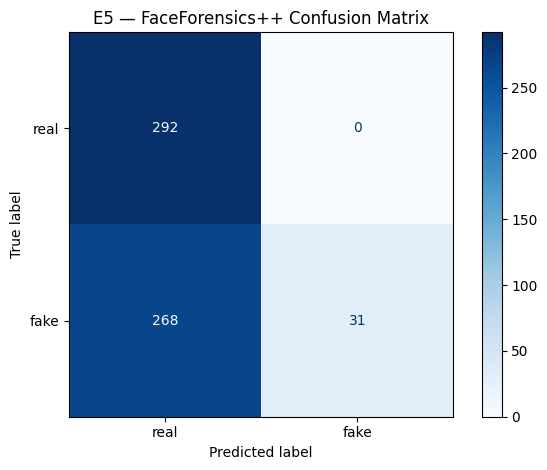

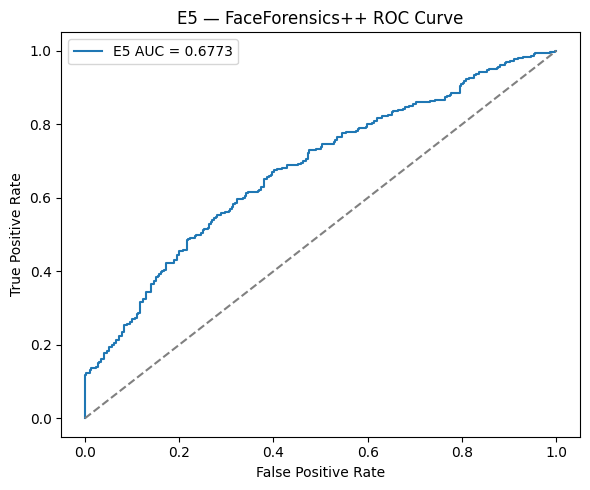

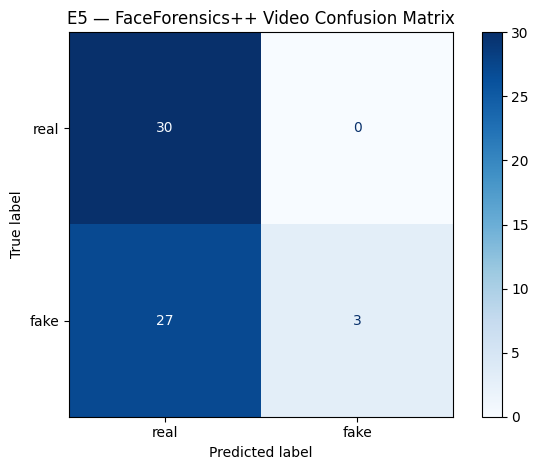

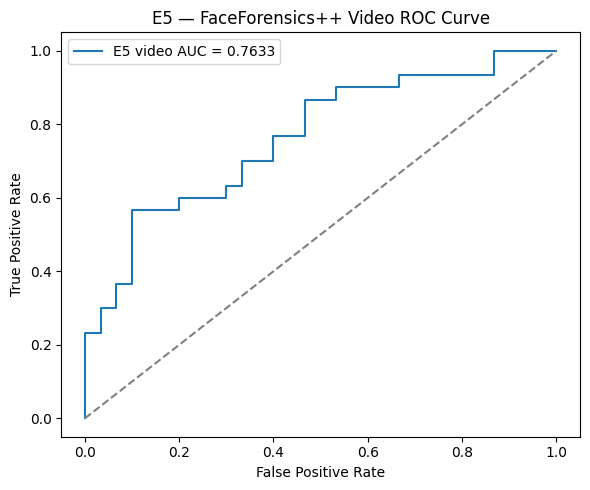

Results saved to: /content/drive/MyDrive/deepfake_project/results/e5_b4_ffpp_evaluation.json
Confusion matrix saved to: /content/drive/MyDrive/deepfake_project/plots/e5_b4_ffpp_confusion_matrix.png
ROC curve saved to: /content/drive/MyDrive/deepfake_project/plots/e5_b4_ffpp_roc_curve.png
Video confusion matrix saved to: /content/drive/MyDrive/deepfake_project/plots/e5_b4_ffpp_video_confusion_matrix.png
Video ROC curve saved to: /content/drive/MyDrive/deepfake_project/plots/e5_b4_ffpp_video_roc_curve.png


In [8]:
if RUN_EVALUATION:
    binary_fake_labels = (
        np.asarray(all_labels) == FAKE_INDEX
    ).astype(int)

    accuracy = accuracy_score(all_labels, all_predictions)
    macro_precision = precision_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )
    macro_recall = recall_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )
    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )
    fake_recall = recall_score(
        all_labels,
        all_predictions,
        labels=[FAKE_INDEX],
        average="macro",
        zero_division=0,
    )
    roc_auc = roc_auc_score(
        binary_fake_labels,
        all_fake_probabilities,
    )

    video_records = {}
    for video_id, label, fake_probability in zip(
        all_video_ids,
        all_labels,
        all_fake_probabilities,
    ):
        record = video_records.setdefault(
            video_id,
            {"label": label, "fake_probabilities": []},
        )
        if record["label"] != label:
            raise RuntimeError(
                f"Inconsistent frame labels for source video {video_id}"
            )
        record["fake_probabilities"].append(fake_probability)

    video_ids = sorted(video_records)
    video_labels = [video_records[v]["label"] for v in video_ids]
    video_fake_probabilities = [
        float(np.mean(video_records[v]["fake_probabilities"]))
        for v in video_ids
    ]
    video_predictions = [
        FAKE_INDEX if probability >= DECISION_THRESHOLD else REAL_INDEX
        for probability in video_fake_probabilities
    ]
    binary_video_fake_labels = (
        np.asarray(video_labels) == FAKE_INDEX
    ).astype(int)

    video_accuracy = accuracy_score(video_labels, video_predictions)
    video_macro_precision = precision_score(
        video_labels, video_predictions, average="macro", zero_division=0
    )
    video_macro_recall = recall_score(
        video_labels, video_predictions, average="macro", zero_division=0
    )
    video_macro_f1 = f1_score(
        video_labels, video_predictions, average="macro", zero_division=0
    )
    video_fake_recall = recall_score(
        video_labels,
        video_predictions,
        labels=[FAKE_INDEX],
        average="macro",
        zero_division=0,
    )
    video_roc_auc = roc_auc_score(
        binary_video_fake_labels, video_fake_probabilities
    )

    ordered_labels = [REAL_INDEX, FAKE_INDEX]
    ordered_names = ["real", "fake"]
    matrix = confusion_matrix(
        all_labels,
        all_predictions,
        labels=ordered_labels,
    )
    video_matrix = confusion_matrix(
        video_labels, video_predictions, labels=ordered_labels
    )
    video_report = classification_report(
        video_labels,
        video_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
    report = classification_report(
        all_labels,
        all_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    print("=" * 65)
    print("E5 — FACEFORENSICS++ FRAME-LEVEL RESULTS")
    print("=" * 65)
    print(f"Frames evaluated : {len(all_labels)}")
    print(f"Accuracy         : {accuracy:.2%}")
    print(f"Macro precision  : {macro_precision:.2%}")
    print(f"Macro recall     : {macro_recall:.2%}")
    print(f"Macro F1-score   : {macro_f1:.2%}")
    print(f"Fake recall      : {fake_recall:.2%}")
    print(f"ROC-AUC          : {roc_auc:.4f}")
    print()
    print(classification_report(
        all_labels,
        all_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
    ))
    print("Confusion matrix [real, fake]:")
    print(matrix)

    print()
    print("=" * 65)
    print("E5 — FACEFORENSICS++ VIDEO-LEVEL RESULTS")
    print("=" * 65)
    print(f"Videos evaluated : {len(video_labels)}")
    print(f"Accuracy         : {video_accuracy:.2%}")
    print(f"Macro precision  : {video_macro_precision:.2%}")
    print(f"Macro recall     : {video_macro_recall:.2%}")
    print(f"Macro F1-score   : {video_macro_f1:.2%}")
    print(f"Fake recall      : {video_fake_recall:.2%}")
    print(f"ROC-AUC          : {video_roc_auc:.4f}")
    print()
    print(classification_report(
        video_labels,
        video_predictions,
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4,
        zero_division=0,
    ))
    print("Confusion matrix [real, fake]:")
    print(video_matrix)

    results = {
        "experiment": "E5",
        "detector": "EfficientNet-B4",
        "evaluation_dataset": "FaceForensics++ test split",
        "evaluation_level": "frame_and_video",
        "checkpoint": CHECKPOINT_PATH,
        "preprocessing": (
            "Precomputed RetinaFace crop saved natively at 380x380 with 15% margin; "
            "scale to [0,1]; "
            "no ImageNet mean/std normalisation"
        ),
        "stored_crop_resolution": "380x380",
        "model_input_resolution": "380x380",
        "primary_control": "E3d EfficientNet-B4/380 with official SBI",
        "independent_variable": (
            "Official frozen FPNet/DCT FreqBlender intervention applied to "
            "approximately 20% of dynamically generated SBI fakes during training"
        ),
        "matched_test_subset": True,
        "fpnet_loaded_during_test": False,
        "dct_used_during_test": False,
        "synthetic_sbi_used_during_test": False,
        "freqblender_used_during_test": False,
        "class_to_idx": {"real": REAL_INDEX, "fake": FAKE_INDEX},
        "fake_output_index": FAKE_INDEX,
        "decision_threshold": DECISION_THRESHOLD,
        "frames_evaluated": len(all_labels),
        "source_videos_evaluated": len(actual_test_video_ids),
        "split_manifest_path": SPLIT_MANIFEST_PATH,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "fake_recall": fake_recall,
        "roc_auc": roc_auc,
        "confusion_matrix_order": ordered_names,
        "confusion_matrix": matrix.tolist(),
        "classification_report": report,
        "video_level": {
            "aggregation": "mean fake probability across frames",
            "videos_evaluated": len(video_labels),
            "accuracy": video_accuracy,
            "macro_precision": video_macro_precision,
            "macro_recall": video_macro_recall,
            "macro_f1": video_macro_f1,
            "fake_recall": video_fake_recall,
            "roc_auc": video_roc_auc,
            "confusion_matrix_order": ordered_names,
            "confusion_matrix": video_matrix.tolist(),
            "classification_report": video_report,
        },
    }

    os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
    os.makedirs(os.path.dirname(CONFUSION_PLOT_PATH), exist_ok=True)

    with open(RESULTS_PATH, "w") as results_file:
        json.dump(results, results_file, indent=4)

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=ordered_names,
    )
    display.plot(cmap="Blues", values_format="d")
    plt.title("E5 — FaceForensics++ Confusion Matrix")
    plt.tight_layout()
    plt.savefig(CONFUSION_PLOT_PATH, dpi=200)
    plt.show()

    false_positive_rate, true_positive_rate, _ = roc_curve(
        binary_fake_labels,
        all_fake_probabilities,
    )
    plt.figure(figsize=(6, 5))
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"E5 AUC = {roc_auc:.4f}",
    )
    plt.plot([0, 1], [0, 1], "--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("E5 — FaceForensics++ ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ROC_PLOT_PATH, dpi=200)
    plt.show()

    video_display = ConfusionMatrixDisplay(
        confusion_matrix=video_matrix,
        display_labels=ordered_names,
    )
    video_display.plot(cmap="Blues", values_format="d")
    plt.title("E5 — FaceForensics++ Video Confusion Matrix")
    plt.tight_layout()
    plt.savefig(VIDEO_CONFUSION_PLOT_PATH, dpi=200)
    plt.show()

    video_fpr, video_tpr, _ = roc_curve(
        binary_video_fake_labels, video_fake_probabilities
    )
    plt.figure(figsize=(6, 5))
    plt.plot(video_fpr, video_tpr, label=f"E5 video AUC = {video_roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], "--", color="grey")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("E5 — FaceForensics++ Video ROC Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig(VIDEO_ROC_PLOT_PATH, dpi=200)
    plt.show()

    print("Results saved to:", RESULTS_PATH)
    print("Confusion matrix saved to:", CONFUSION_PLOT_PATH)
    print("ROC curve saved to:", ROC_PLOT_PATH)
    print("Video confusion matrix saved to:", VIDEO_CONFUSION_PLOT_PATH)
    print("Video ROC curve saved to:", VIDEO_ROC_PLOT_PATH)


## Interpretation boundary

This is a matched internal comparison between E5 and E3d. Both detectors use EfficientNet-B4, native 380×380 crops, the same clean FF++ training/validation source split, the same training budget and the exact same 591 genuine FF++ test-frame identities from 60 videos.

The intended difference is the official FreqBlender intervention applied to approximately 20% of SBI pseudo-fakes during E5 training. Therefore, a difference relative to E3d can be attributed to the FreqBlender-augmented training procedure within the limits of stochastic training.

Do not claim improved generalisation from this internal result. The generalisation hypothesis must be tested separately on the fixed Celeb-DF pilot without retraining, adaptation or threshold tuning. Accuracy should be interpreted jointly with macro F1, fake recall and ROC-AUC because earlier SBI models showed strong ranking ability but weak fake detection at threshold 0.5.
